### Short-Term Memory with the InMemorySaver Class

In [1]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, RemoveMessage
from langgraph.checkpoint.memory import InMemorySaver

from config import OPEN_AI_KEY as API_KEY

chat = ChatOpenAI(model="gpt-5.6-luna", seed=365, temperature=0, api_key=API_KEY)

class CustomState(MessagesState):
    summary: str

In [4]:
def ask_question(state: CustomState) -> CustomState:
    print("\n----------------> Entering Ask Question Phase:")
    question = "What is your question?"
    answer = input()
    print(question, "\n", answer)
    return CustomState(messages=[AIMessage(question), HumanMessage(answer)])

def chatbot(state: CustomState) -> CustomState:
    print("\n----------------> Entering ChatBot:")
    _msg = f"""Here's a quick summary of what's been discussed so far: {state.get("summary", "")}
Keep this in mind as you answer the next question.
"""
    _response = chat.invoke([SystemMessage(_msg)] + state.get("messages"))
    _response.pretty_print()
    return CustomState(messages=[_response])

def summarize_and_delete_messages(state: CustomState) -> CustomState:
    print("\n----------------> Summarizing & Deleting Messages:")

    new_convo = ""
    for _msg in state["messages"]:
        new_convo += f"{_msg.type.capitalize()}: {_msg.content.capitalize()}\n\n"

    instructions = f"""Update the ongoing summary by incorporating the new lines of conversations below.
Build upon the previous summary rather than repeating it, so that the result reflects the most recent context & developments.
Respond only with the summary.

Previous Summary: {state.get("summary", "")}

New Conversation: {new_convo}
"""

    summary = chat.invoke([HumanMessage(instructions)])
    remove_messages = [RemoveMessage(id=_msg.id) for _msg in state.get("messages")]
    summary.pretty_print()
    return CustomState(messages=remove_messages, summary=summary.content)

In [5]:
graph = StateGraph(CustomState)

graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("summarize_messages", summarize_and_delete_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "summarize_messages")
graph.add_edge("summarize_messages", END)

checkpointer = InMemorySaver()
graph_compiled = graph.compile(checkpointer)

In [6]:
# Let's compile the graph and instruct it to create in-memory checkpoints, associating them with a specific thread.
config_1 = {"configurable": {"thread_id": 1}}
response = graph_compiled.invoke(CustomState(), config_1)
# PS: You can use multiple threads i.e., config_2 = {"configurable": {"thread_id": 2}}


----------------> Entering Ask Question Phase:
What is your question? 
 In less than 100 words, can you tell me about Godot 4?

----------------> Entering ChatBot:
================================== Ai Message ==================================

Godot 4 is a free, open-source game engine for creating 2D and 3D games, simulations, and interactive applications. It includes a scene-based workflow, visual editors, physics, animation tools, networking, and scripting through GDScript, C#, or C++. Compared with Godot 3, it offers improved rendering, performance, lighting, terrain tools, and usability. Godot supports desktop, mobile, web, and some console development through third-party solutions. Its permissive MIT license allows developers to use, modify, and distribute their projects without royalties.

----------------> Summarizing & Deleting Messages:
================================== Ai Message ==================================

The conversation covered Godot 4, describing it as a fre

In [7]:
response

{'messages': [],
 'summary': 'The conversation covered Godot 4, describing it as a free, open-source game engine for developing 2D and 3D games, simulations, and interactive applications. Key features include scene-based workflows, visual editors, physics, animation, networking, and scripting with GDScript, C#, or C++. Compared with Godot 3, it improves rendering, performance, lighting, terrain tools, and usability. It supports desktop, mobile, web, and some console development through third-party solutions, and uses a permissive MIT license with no royalties.'}

In [10]:
graph_compiled.invoke(CustomState(), config_1)


----------------> Entering Ask Question Phase:
What is your question? 
 I'm more focused on graphics and not trying to do a remake or for PS2. It's for PC. Just wanted to know if Godot 4 can handle something like that.

----------------> Entering ChatBot:
================================== Ai Message ==================================

Yes. **Godot 4 can handle a PC game with 3D graphics similar to a modernized or stylized version of *Def Jam: Fight for NY*.** You are not limited to PS2-level visuals.

Godot 4 supports:

- Fully 3D environments and characters
- Skeletal animation and animation blending
- Dynamic lighting and shadows
- Normal maps, roughness, metallic materials, and shaders
- Particle effects, fire, smoke, sparks, and destruction effects
- Post-processing such as bloom, color grading, ambient occlusion, and depth of field
- Large detailed arenas
- Physics-based environmental objects
- High-resolution textures and modern PC resolutions
- Gamepad, keyboard, ultrawide, an

{'messages': [],
 'summary': 'The project is now clarified as an original PC game focused on graphics, not a remake and not intended for PS2 hardware. Godot 4 can support a modernized or stylized 3D arena fighter with visuals well beyond the PS2 era, including detailed environments and characters, skeletal animation and blending, dynamic lighting and shadows, PBR materials, particles, destruction, shaders, post-processing, high-resolution textures, and modern PC display and controller support.\n\nThe Forward+ renderer would suit higher-end PCs and advanced lighting, while the Mobile renderer could target lower-end systems and the Compatibility renderer would provide broader hardware support with fewer graphical features. Godot’s primary limitations are practical rather than fundamental: creating high-quality models, clothing, hair, facial expressions, combat animations, hit reactions, grapples, and throws; optimizing polygon counts, textures, draw calls, shadows, particles, and physics

In [14]:
graph_states = [state for state in graph_compiled.get_state_history(config_1)]

In [23]:
for state in graph_states[::-1]: # Reverses the order as the latest is first
    print(f"""
Messages: {state.values["messages"]}
Summary: {state.values.get("summary", "")}
Next: {state.next}
Step: {state.metadata["step"]}
""")


Messages: []
Summary: 
Next: ('__start__',)
Step: -1


Messages: []
Summary: 
Next: ('ask_question',)
Step: 0


Messages: [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='ecb8da9e-6ac3-41f1-9f5e-2b091045af54', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='In less than 100 words, can you tell me about Godot 4?', additional_kwargs={}, response_metadata={}, id='98ecb9d8-bf4d-491d-a4da-d161f2785b9f')]
Summary: 
Next: ('chatbot',)
Step: 1


Messages: [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='ecb8da9e-6ac3-41f1-9f5e-2b091045af54', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='In less than 100 words, can you tell me about Godot 4?', additional_kwargs={}, response_metadata={}, id='98ecb9d8-bf4d-491d-a4da-d161f2785b9f'), AIMessage(content='Godot 4 is a free, open-source game engine for creating 2D and 3D games, simulations, and interactive applications. It includes a sce

### Long-Term Memory with SQLite3

In [27]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

db_path = r"./db.sqlite3"
conn = sqlite3.connect(database=db_path, check_same_thread=False)

checkpointer = SqliteSaver(conn)
graph_compiled = graph.compile(checkpointer)

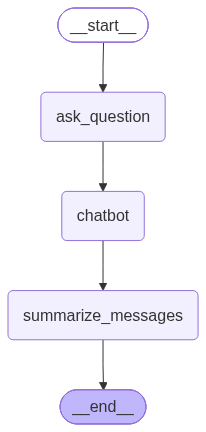

In [28]:
graph_compiled